In [37]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Combine datasets

In [38]:
gaming_data = pd.read_csv('../data/gaming_GAD_CLEAN.csv')
nhis_data = pd.read_csv('../data/nhis_GAD_CLEAN.csv')

In [39]:
set(gaming_data.columns) ^ set(nhis_data.columns)

{'Degree',
 'Gender',
 'game',
 'hours',
 'participant_id_OLD',
 'platform',
 'playstyle',
 'reason',
 'region_id'}

In [40]:
df = pd.concat([gaming_data, nhis_data], ignore_index=True, sort=False)
df.head()

# Reference: https://pandas.pydata.org/docs/user_guide/merging.html

,Unnamed: 0,participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,Degree,age,survey_id,education_id,residence,game,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD
0,0,1,2015,0,0,0,0,1,0,0,1,1,1,Bachelor (or equivalent),25,1,8,USA,Skyrim,"Console (PS, Xbox, ...)",15.0,having fun,Singleplayer,Male,NaN,NaN
1,1,2,2015,1,2,2,2,0,1,0,8,2,1,Bachelor (or equivalent),41,1,8,USA,Other,PC,8.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN
2,2,3,2015,0,2,2,0,0,3,1,8,2,2,Bachelor (or equivalent),32,1,8,DEU,Other,PC,0.0,having fun,Singleplayer,Female,NaN,NaN
3,3,4,2015,0,0,0,0,0,0,0,0,1,1,Bachelor (or equivalent),28,1,8,USA,Other,PC,20.0,improving,Multiplayer - online - with online acquaintanc...,Male,NaN,NaN
4,4,5,2015,2,1,2,2,2,3,2,14,3,1,High school diploma (or equivalent),19,1,12,KOR,Other,"Console (PS, Xbox, ...)",20.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN


In [41]:
# This remains from an unknown issue before where both datasets had a participant with this id
filtered_data = df.loc[df['participant_id'] == 43]
filtered_data

,Unnamed: 0,participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,Degree,age,survey_id,education_id,residence,game,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD
42,42,43,2015,0,0,0,0,0,0,0,0,1,1,Bachelor (or equivalent),27,1,8,USA,Other,PC,12.0,having fun,Multiplayer - online - with strangers,Male,NaN,NaN


In [42]:
# Confirming that the data fix was successful

filtered_data = df.loc[df['GAD_total'] > 21]
filtered_data

# GAD_total needs to be recalculated after data correction

,Unnamed: 0,participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,Degree,age,survey_id,education_id,residence,game,platform,hours,reason,playstyle,Gender,region_id,participant_id_OLD


In [43]:
df['GAD_total'].unique()

array([ 1,  8,  0, 14, 12, 10, 19,  3,  2,  4, 15,  5,  6,  7, 13, 11,  9,
       18, 16, 21, 17, 20])

# Build Relational Tables

In [44]:
# ================
# Fact tables
# ================

participant_df = df[['participant_id', 'survey_id', 'sex_id', 'education_id', 'residence', 'age', 'region_id']].drop_duplicates()

GAD_response_df = df[['participant_id', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'GAD_total', 'GAD_cat']]

gamers_df = df[['participant_id', 'survey_id', 'game', 'platform', 'hours', 'reason', 'playstyle']].drop_duplicates()

# ================
# Lookup tables
# ================

survey_df = pd.DataFrame({
    'survey_id': [1, 2],
    'survey_name': ['Gamers', 'NHIS'],
    'year': [2015, 2019],
    'population':['global', 'America']
})


GAD_categories = {
    1:'None/Minimal', 
    2:'Mild', 
    3:'Moderate', 
    4:'Severe', 
    8:'Not Ascertained'
}

GAD_cat_df = (
    pd.Series(GAD_categories, name='cat_name')
        .rename_axis('GAD_cat')
        .reset_index()
)

sex_lookup = {
    1: 'Male', 
    2:'Female', 
    7:'Refused', 
    8:'Not Ascertained',
    9:"Don't Know"
}
sex_df = (
    pd.Series(sex_lookup, name='sex_name')
        .rename_axis('sex_id')
        .reset_index()
)


degree_lookup = {
    0:'Never attended/kindergarten only', 
    1: 'Grade 1-11',
    2: '12th grade, no diploma',
    3: 'GED or equivalent',
    4: 'High School Graduate',
    5: 'Some college, no degree',
    6: 'Associate degree: occupational, technical, or vocational program',
    7: 'Associate degree: academic program',
    8: "Bachelor's degree (Example: BA, AB, BS, BBA)",
    9: "Master's degree or equivalent (Example: MA, MS, MEng, MEd, MBA)",
    10: "Professional School degree (Example: MD, DDS, DVM, JD)",
    11: "Doctoral degree (Example: PhD, EdD)",
    12: "High school diploma (or equivalent)",
    13: "Ph.D., Psy. D., MD (or equivalent)",
    97: "Refused",
    98: "Not Ascertained",
    99:"Don't Know"
}
education_df = (
    pd.Series(degree_lookup, name='level')
        .rename_axis('education_id')
        .reset_index()
)


region_lookup = {
    1: 'Northeast',
    2: 'Midwest',
    3: 'South', 
    4: 'West'
}
region_df = (
    pd.Series(region_lookup, name='name')
        .rename_axis('region_id')
        .reset_index()
)

# I conferred with ChatGPT to decide how to set up the lookup tables
# it recommended using dictionaries to set them up to make it easier to 
# read and maintain. I did this for the longer ones

In [45]:
conn = sqlite3.connect('../data/mentalhealth.db')

participant_df.to_sql('participants', conn, index=False, if_exists='replace')
GAD_response_df.to_sql('responses', conn, index=False, if_exists='replace')
gamers_df.to_sql('gamers', conn, index=False, if_exists='replace')
survey_df.to_sql('survey', conn, index=False, if_exists='replace')
GAD_cat_df.to_sql('categories', conn, index=False, if_exists='replace')
sex_df.to_sql('sex', conn, index=False, if_exists='replace')
education_df.to_sql('education', conn, index=False, if_exists='replace')
region_df.to_sql('region', conn, index=False, if_exists='replace')

4

# Exploratory Data Analysis

## QUERIES

### Participant data and scores (all_data_scores_r)

In [46]:
all_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
"""

all_data_scores_r = pd.read_sql(all_data_scores_q, conn)
all_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,3,1,2,8,DEU,32,NaN,0,1,1,1,1,1,1,6,2
3,3,1,2,8,DEU,32,NaN,0,2,2,0,0,3,1,8,2
4,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57451,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
57452,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
57453,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
57454,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


### Participant data and scores (USA) (usa_data_scores_r)

In [47]:
usa_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
WHERE p.residence = "USA"
"""

usa_data_scores_r = pd.read_sql(usa_data_scores_q, conn)
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,NaN,0,0,0,0,0,0,0,0,1
4,6,1,1,8,USA,24,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44407,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
44408,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
44409,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
44410,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


### NHIS data and scores (nhis_data_scores_r)

In [48]:
nhis_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
WHERE p.survey_id = 2
"""

nhis_data_scores_r = pd.read_sql(nhis_data_scores_q, conn)
nhis_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,48109,2,1,7,USA,97,3.0,0,0,0,0,0,0,0,0,1
1,27044,2,2,6,USA,28,3.0,0,0,1,0,0,1,1,3,1
2,58855,2,1,5,USA,72,3.0,0,0,0,0,0,0,0,0,1
3,31993,2,1,7,USA,60,3.0,0,0,0,0,0,0,0,0,1
4,7122,2,1,5,USA,60,3.0,2,1,1,1,0,0,1,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37627,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
37628,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
37629,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
37630,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


### Gamer data and scores (USA) (usa_gamer_data_scores_r)

In [49]:
usa_gamer_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
WHERE p.survey_id = 1
    AND p.residence = "USA"
"""

usa_gamer_data_scores_r = pd.read_sql(usa_gamer_data_scores_q, conn)
usa_gamer_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,None,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,None,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,None,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,None,0,0,0,0,0,0,0,0,1
4,6,1,1,8,USA,24,None,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6775,14240,1,1,12,USA,24,None,3,3,1,3,3,3,0,16,4
6776,14245,1,1,12,USA,21,None,0,0,0,0,0,0,0,0,1
6777,14245,1,1,12,USA,21,None,0,1,1,1,0,2,1,6,2
6778,14247,1,2,12,USA,20,None,0,0,0,0,0,0,0,0,1


### Gamer data and scores (World) (all_gamer_data_scores_r)

In [50]:
all_gamer_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
WHERE p.survey_id = 1
"""

all_gamer_data_scores_r = pd.read_sql(all_gamer_data_scores_q, conn)
all_gamer_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,None,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,None,1,2,2,2,0,1,0,8,2
2,3,1,2,8,DEU,32,None,0,1,1,1,1,1,1,6,2
3,3,1,2,8,DEU,32,None,0,2,2,0,0,3,1,8,2
4,4,1,1,8,USA,28,None,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19819,14247,1,2,12,USA,20,None,3,3,3,3,2,3,3,20,4
19820,14248,1,1,12,NOR,19,None,0,0,0,0,0,0,0,0,1
19821,14248,1,1,12,NOR,19,None,0,0,0,0,0,0,0,0,1
19822,14249,1,2,12,CAN,18,None,3,2,1,3,0,1,3,13,3


### Scores by sex (sex_data_scores_r)

In [51]:
sex_data_scores_q = """
SELECT
    p.sex_id,
    s.sex_name,
    AVG(r.GAD1),
    AVG(r.GAD2),
    AVG(r.GAD3),
    AVG(r.GAD4),
    AVG(r.GAD5),
    AVG(r.GAD6),
    AVG(r.GAD7),
    AVG(r.GAD_total),
    AVG(r.GAD_cat),
    count(p.sex_id) as total_participants
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
JOIN sex s on s.sex_id = p.sex_id
GROUP BY p.sex_id
"""

sex_data_scores_r = pd.read_sql(sex_data_scores_q, conn)
sex_data_scores_r

,sex_id,sex_name,AVG(r.GAD1),AVG(r.GAD2),AVG(r.GAD3),AVG(r.GAD4),AVG(r.GAD5),AVG(r.GAD6),AVG(r.GAD7),AVG(r.GAD_total),AVG(r.GAD_cat),total_participants
0,1,Male,0.531893,0.404154,0.576377,0.449193,0.310306,0.570220,0.336763,3.178906,1.391952,36058
1,2,Female,0.511556,0.428062,0.557686,0.449534,0.259247,0.501102,0.307346,3.014533,1.380854,21331
2,7,Refused,1.666667,1.666667,0.666667,0.666667,0.333333,1.666667,1.000000,7.666667,2.333333,3


### Scores by age (usa_age_data_scores_r)
Note that this *may* skew results somewhat as the primary participants of the gamer survey were in their early 20s.

In [52]:
usa_age_data_scores_q = """
SELECT
    p.age,
    AVG(r.GAD1),
    AVG(r.GAD2),
    AVG(r.GAD3),
    AVG(r.GAD4),
    AVG(r.GAD5),
    AVG(r.GAD6),
    AVG(r.GAD7),
    AVG(r.GAD_total),
    AVG(r.GAD_cat),
    count(p.age) as total_participants
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
GROUP BY p.age
"""

usa_age_data_scores_r = pd.read_sql(usa_age_data_scores_q, conn)
usa_age_data_scores_r

,age,AVG(r.GAD1),AVG(r.GAD2),AVG(r.GAD3),AVG(r.GAD4),AVG(r.GAD5),AVG(r.GAD6),AVG(r.GAD7),AVG(r.GAD_total),AVG(r.GAD_cat),total_participants
0,18,0.676918,0.535848,0.773824,0.564098,0.391024,0.776506,0.480780,4.198999,1.543179,5593
1,19,0.656928,0.508533,0.737923,0.524732,0.373445,0.699450,0.440845,3.941857,1.495806,3457
2,20,0.682927,0.547176,0.762516,0.564185,0.386714,0.690308,0.443196,4.077022,1.525995,3116
3,21,0.685804,0.534801,0.748329,0.578451,0.379866,0.683052,0.457334,4.067637,1.521825,2543
4,22,0.704390,0.566341,0.778049,0.595122,0.355610,0.673659,0.418537,4.091707,1.516098,2050
...,...,...,...,...,...,...,...,...,...,...,...
65,83,0.425197,0.354331,0.460630,0.291339,0.185039,0.393701,0.287402,2.397638,1.299213,254
66,84,0.306977,0.320930,0.390698,0.255814,0.162791,0.293023,0.195349,1.925581,1.195349,215
67,85,0.406026,0.315638,0.398852,0.296270,0.190818,0.322812,0.250359,2.180775,1.253945,1394
68,97,0.343284,0.283582,0.343284,0.238806,0.164179,0.343284,0.149254,1.865672,1.283582,67


### Scores by education (all_gamer_data_scores_r)

In [53]:
all_gamer_data_scores_q = """
SELECT
    p.education_id,
    AVG(r.GAD1),
    AVG(r.GAD2),
    AVG(r.GAD3),
    AVG(r.GAD4),
    AVG(r.GAD5),
    AVG(r.GAD6),
    AVG(r.GAD7),
    AVG(r.GAD_total),
    AVG(r.GAD_cat),
    count(p.education_id) as total_participants
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
GROUP BY p.education_id
"""

all_gamer_data_scores_r = pd.read_sql(all_gamer_data_scores_q, conn)
all_gamer_data_scores_r

,education_id,AVG(r.GAD1),AVG(r.GAD2),AVG(r.GAD3),AVG(r.GAD4),AVG(r.GAD5),AVG(r.GAD6),AVG(r.GAD7),AVG(r.GAD_total),AVG(r.GAD_cat),total_participants
0,0,0.388350,0.242718,0.281553,0.368932,0.281553,0.349515,0.252427,2.165049,1.233010,103
1,1,0.546763,0.485971,0.606835,0.482374,0.367266,0.530576,0.381295,3.401079,1.446403,2780
2,2,0.426987,0.364140,0.486137,0.367837,0.301294,0.489834,0.279113,2.715342,1.345656,541
3,3,0.599558,0.545354,0.678097,0.565265,0.418142,0.609513,0.361726,3.777655,1.508850,904
4,4,0.420113,0.356756,0.471605,0.365165,0.246285,0.444073,0.265983,2.569980,1.317705,8681
5,5,0.469915,0.361184,0.491007,0.405003,0.259810,0.486756,0.268640,2.742315,1.340582,6116
6,6,0.453306,0.386503,0.488071,0.419905,0.271984,0.482618,0.263122,2.765508,1.342877,1467
7,7,0.435263,0.350015,0.478324,0.377946,0.237707,0.472796,0.258947,2.610998,1.315682,3437
8,8,0.500737,0.366508,0.516615,0.428712,0.253069,0.496071,0.282207,2.843919,1.342855,12218
9,9,0.441347,0.302809,0.440703,0.362642,0.201158,0.430410,0.226893,2.405962,1.273429,4663


## Visualizations

- box & whisker plot of scores (total and by survey)

### Heat map: Is there an observable and unexptected correlation in the data?

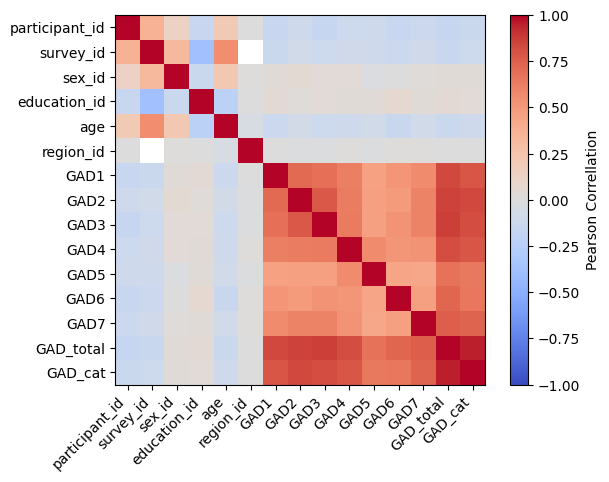

In [54]:
numeric_usa_df = usa_data_scores_r.select_dtypes(include=[np.number])
corr = numeric_usa_df.corr()

im = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(im, label='Pearson Correllation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

There do not appear to be any strong, unexpected correlations revealed by this heat map.

### Pie chart: What is the division of participants' identified sex?

In [55]:
category = 'sex_name'
values = 'total_participants'

sex_totals = sex_data_scores_r.groupby(category)[values].sum()
sex_totals

sex_name
Female     21331
Male       36058
Refused        3
Name: total_participants, dtype: int64

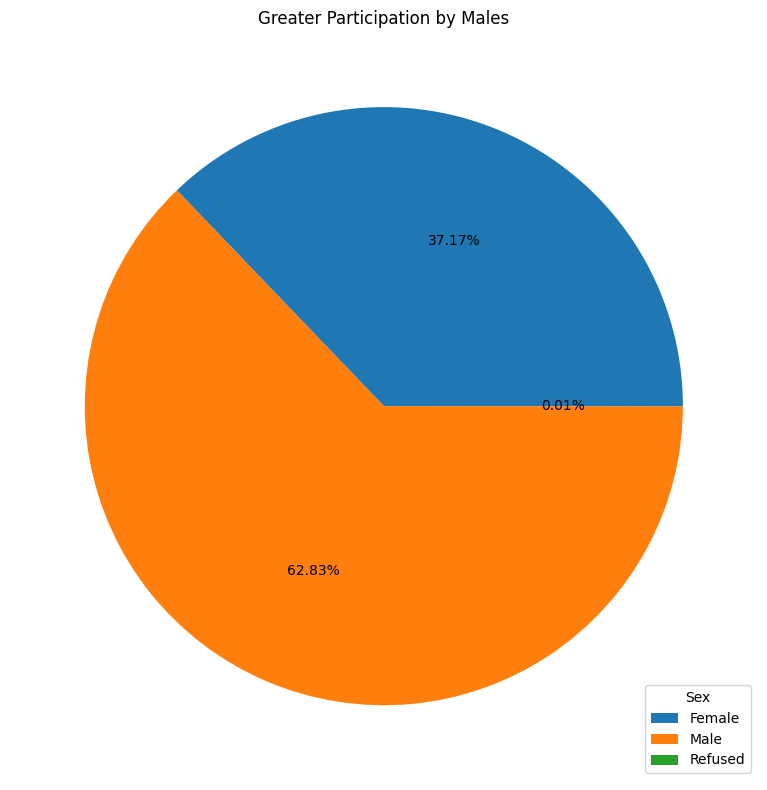

In [56]:
plt.figure(figsize=(8,8))
plt.pie(
    sex_totals,
    labels=None,
    autopct='%1.2f%%'
)

plt.title('Greater Participation by Males')

plt.legend(
    labels=sex_totals.index,
    loc='lower right',
    title='Sex'
)

plt.tight_layout()
plt.show()

### Bar chart: What is the average GAD score for each survey? (USA)

In [57]:
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,NaN,0,0,0,0,0,0,0,0,1
4,6,1,1,8,USA,24,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44407,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
44408,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
44409,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
44410,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


In [58]:
avg_score = usa_data_scores_r.groupby('survey_id')['GAD_total'].mean()
avg_score

survey_id
1    4.220649
2    2.582802
Name: GAD_total, dtype: float64

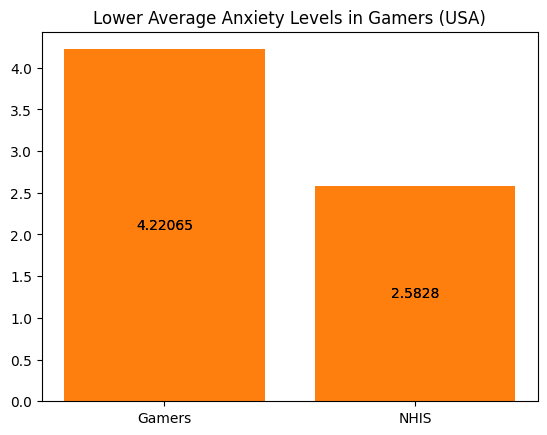

In [59]:
surveys = ('Gamers', 'NHIS')

fig, ax = plt.subplots()
bottom = np.zeros(2)

for survey in avg_score.items():
    p = ax.bar(surveys, avg_score, label=survey, bottom=bottom)
    ax.bar_label(p, label_type='center')

ax.set_title('Lower Average Anxiety Levels in Gamers (USA)')

plt.show()

# Reference: 
#   x-tick labels: https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html

### Count plots of avg scores
  - totals
  - by survey
  - (total and by survey)
    - by sex
    - by age
    - by education

#### How do the GAD score totals compare across all participants?

In [60]:
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,NaN,0,0,0,0,0,0,0,0,1
4,6,1,1,8,USA,24,NaN,0,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44407,46022,2,2,7,USA,68,4.0,0,0,0,0,0,0,0,0,1
44408,46232,2,1,5,USA,47,4.0,0,0,0,0,0,0,0,0,1
44409,43765,2,1,5,USA,68,4.0,0,0,0,0,0,1,0,1,1
44410,17695,2,2,7,USA,31,4.0,0,0,1,0,0,0,0,1,1


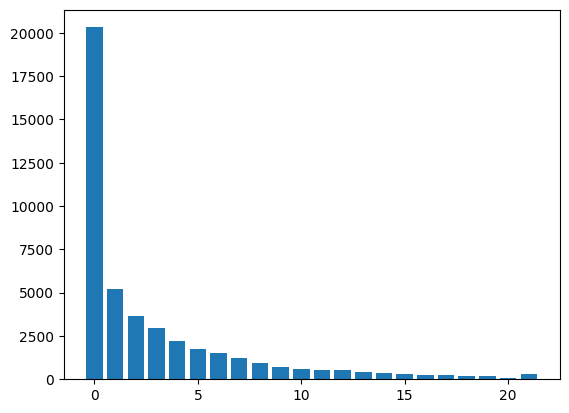

In [61]:
usa_score_count = usa_data_scores_r['GAD_total'].value_counts()

plt.bar(usa_score_count.index, usa_score_count.values)

plt.show()

In [62]:
# investigating  why any number is above total possible GAD score of 21
usa_data_scores_r['GAD_total'].unique()

array([ 1,  8,  0,  3, 12, 19,  4,  6, 14,  7,  5, 11,  2, 10, 18, 21,  9,
       17, 15, 16, 13, 20])

In [63]:
filtered_scores = usa_data_scores_r.loc[usa_data_scores_r['GAD_total'] > 21]
filtered_scores

# I'm stepping away for now. The highest number that SHOULD be possible in the GAD1-7 columns is 3.

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat


#### How do the GAD score totals compare across USA gamer participants?

#### How do the GAD score totals compare across NHIS participants?